## Import Libs

In [1]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

# sns.set_style('darkgrid')

from pathlib import Path
# research_path = Path('../') # 'utils_functionality/')

import os
import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc

## Drag coefficient plot 

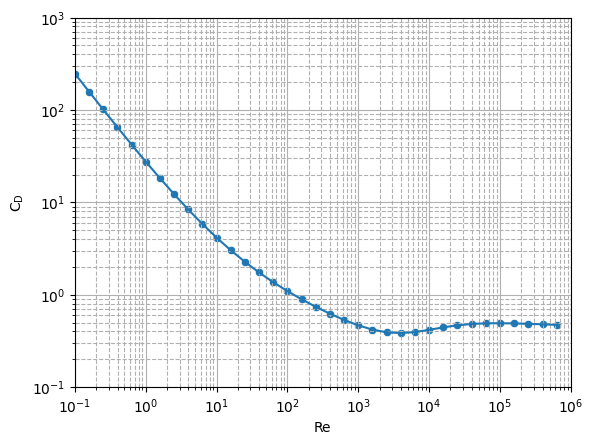

In [2]:
power = np.arange(-2, 6, step=0.2)
Re_vec = 10**power

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
)
sns.scatterplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1*10**-1, 10**6)
ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$');

## Reynolds calculation and drag coefficient plot

velocity [m/s]:
[0.1        0.12589254 0.15848932 0.19952623 0.25118864 0.31622777
 0.39810717 0.50118723 0.63095734 0.79432823 1.         1.25892541
 1.58489319 1.99526231 2.51188643 3.16227766 3.98107171 5.01187234
 6.30957344]

Reynolds number:
[  19.79   24.92   31.37   39.49   49.71   62.59   78.79   99.19  124.88
  157.21  197.92  249.16  313.68  394.9   497.15  625.87  787.92  991.94
 1248.78]


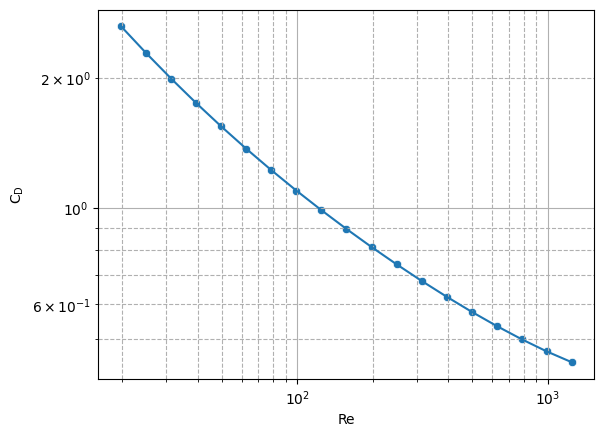

In [3]:
print('velocity [m/s]:')
power = np.arange(-1, 0.9, step=0.1)
velocity = 10**power
print(velocity)
print('')
print('Reynolds number:')
Re_vec = vc.get_Re(
    velocity=velocity,
    diameter=3e-3, # droplet diameter [m]
    density=1.204, # air density [kg/m^3]
    viscosity=1.825e-5, # air dynamic viscosity [Pa*s]
)
print(np.round(Re_vec,2))

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
)
sns.scatterplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(1*10**-1, 10**6)
# ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$');

## Right hand side

In [4]:
system = vc.DropFallSystem(
    init_state=np.array([1.8, 0.])
)

print('First step RHS')
system.compute_closed_loop_rhs(
    time=0,
    state=system.init_state
)

Standard parameters are set
{'drop_diameter': 0.003, 'gas_density': 1.204, 'gas_viscosity': 1.825e-05, 'drop_density': 998.2, 'free_fall_acceleration': 9.81}
First step RHS


array([-0.  ,  9.81])

## Get fall time and impact velocity

In [13]:
height = 1.8
drop_diameter = 3.0e-3
drop_density = 998.2

vc.get_impact_velocity(
    height=height,
    drop_diameter=drop_diameter,
    drop_density=drop_density,
    verbose=True
)

Time of fall: 0.636
Last state: [-4.44089210e-16  5.23359605e+00]


5.233596051236658

## Plot free fall velocity and velocity with the drag force

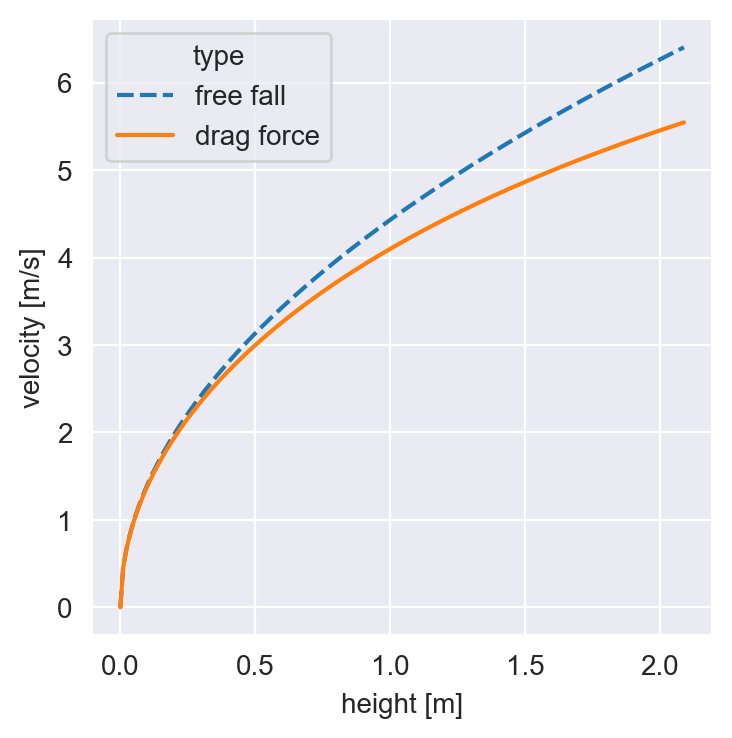

In [70]:
heights = np.arange(0.0, 2.1, step=0.01, )
drop_diameter = 3.0e-3
drop_density = 998.2
# display(heights)

free_fall_velocities = np.sqrt(
    2*system._parameters['free_fall_acceleration']*heights
)
# print('Free fall impact velocity')
# display(free_fall_velocities)

impact_velocities = np.array(list(
    map(
        lambda h: vc.get_impact_velocity(
            height=h,
            drop_diameter=drop_diameter,
            drop_density=drop_density,
        ),
        list(heights)
    )
))
# print('Impact velocity with drag coefficient')
# display(impact_velocities)

free_fall_df = pd.DataFrame(
    {
        'height [m]': heights,
        'velocity [m/s]': free_fall_velocities,
        'type': 'free fall',
    }
)

drag_df = pd.DataFrame(
    {
        'height [m]': heights,
        'velocity [m/s]': impact_velocities,
        'type': 'drag force',
    }
)

velocities_df = pd.concat(
    [
        free_fall_df,
        drag_df
        
    ],
    ignore_index=True,
    axis=0
)

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=200)

sns.set_style('darkgrid')
sns.lineplot(
    data=velocities_df,
    x='height [m]',
    y='velocity [m/s]',
    hue='type',
    style='type',
    style_order=['drag force', 'free fall'],
    ax=ax
);